# DCA Workshop
This is a Jupyter notebook guide to running a Direct Coupling Analysis with mfDCA.

While this script can be run start to finish with no effort on your part by hitting the "Run All" button, the goal is ultimately for you to understand at every step what is happening.

I encourage you to open the files and try to understand what is contained in them.

BEFORE running, make sure to follow the README in the github to set up an environment to run this.

This guide will cover:
 - Downloading an MSA from Pfam
 - Filtering the MSA to improve DCA results
 - Downloading a PDB and pulling the fasta file and native contacts from it.
 - Aligning the PDB fasta to the Pfam MSA.
 - Ranking, filtering, and plotting DI pairs.

N. B.: There are some exercises that require the use of HMMER. If you have not used HMMER before, the official website has easy installation guides and you can also find tutorials online. If you have trouble installing or using HMMER, please reach out to me and I can help you get set up. Keep in mind that HMMER can only be used in a Unix system, if you are on Windows, you will need to use WSL or a virtual machine to run HMMER.

In [2]:
from collections import defaultdict
from requests import get
from dca import dca_class, dca_analysis, helper_functions, hmm_tools
from Bio import SeqIO 
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import gzip
import pickle

def unZipFile(ZipFile, OutputFile = None):
    if OutputFile == None:
        OutputFile = ZipFile.with_suffix('')
    with gzip.open(ZipFile, 'rb') as f_in:
        with open(OutputFile, 'wb') as f_out:
            for line in f_in:
                f_out.write(line)
    ZipFile.unlink()

dataDir = Path('./dataDCA')
figDir = Path('./figuresDCA')

# checks for a data folder; outputs all files to data folder
dataDir.mkdir(parents=True, exist_ok=True)
figDir.mkdir(parents=True, exist_ok=True)

## The problem
Usually all problems we tackle using evolutionary tools begin with an specific protein in an organism. In this case we will work with two different version of the same protein, Superoxide Dismutase (SOD), which is a very common enzyme that protects the cell from oxidative damage by catalyzing the conversion of superoxide radicals to oxygen and hydrogen peroxide. We will compare both the human and the Tuberculosis version of SOD, which have different structures and dimerization properties while sharing the same function. The human version is a homodimer that contains a copper and a zinc ion in each monomer, while the tuberculosis version is a homodimer that is missing the zinc ion. Let's start by downloading the structures and their native contacts.

## Step 1: Getting the structure and native contacts
We are downloading our PDBs from https://www.rcsb.org, the Protein Data Bank. You can retrieve the files directly from the website, or you can use the PDB IDs to download them programmatically. The PDB IDs for the two structures we will be working with are:
- Human SOD: 1AZV
- Tuberculosis SOD: 1PZS

PDB provides the structure of the protein, which is a 3D representation of the positions of all the atoms in the protein, in both .pdb and .cif formats. The .cif format is a more modern format that contains more information and is easier to parse, while the .pdb format is an older format that is still widely used. We will be using the .cif format for our analysis. However, we will also download the .pdb files since they are easier to read and they are still widely used. We will also need the .fasta files, which contain the amino acid sequence of the protein. The .fasta files can be obtained from the PDB website as well, or they can be extracted from the .cif files.

In [2]:
# Downloading PDB file...
pdbID_1 = '1AZV'
pdbID_2 = '1PZS'

# Downloading PDB cif and legacy pdb files:
def download_pdb_files(fileName, Dir=dataDir):
    pdb_request = get('https://files.rcsb.org/download/'+fileName)
    fileHandle = Dir.joinpath(fileName)
    with open( fileHandle ,'wb') as fd:
        fd.write(pdb_request.content)
    return fileHandle

pdbFile1 = download_pdb_files(pdbID_1+'.pdb')
pdbFile2 = download_pdb_files(pdbID_2+'.pdb')
cifFile1 = download_pdb_files(pdbID_1+'.cif')
cifFile2 = download_pdb_files(pdbID_2+'.cif')

#Downloading fasta files:
structSeq1 = dataDir.joinpath(pdbID_1+'.fasta')
structSeq2 = dataDir.joinpath(pdbID_2+'.fasta')
pdb_fasta_file = get('https://www.rcsb.org/fasta/entry/'+pdbID_1)
with open( structSeq1 ,'wb') as fd:
    fd.write(pdb_fasta_file.content)
pdb_fasta_file = get('https://www.rcsb.org/fasta/entry/'+pdbID_2)
with open( structSeq2 ,'wb') as fd:
    fd.write(pdb_fasta_file.content)

Now we calculate the native contacts from the PDB files. Native contacts are pairs of residues that are in close proximity in the 3D structure of the protein. We will use a distance cutoff of 8 angstroms to define contacts, which is a common choice in the field. We will use the helper function `get_allatom_contacts` to calculate the contacts, which takes as input the PDB file, the chain IDs, and the distance cutoff. The output is a list of pairs of residues that are in contact. The function checks all atoms in the residues and calculates the distance between them, if any pair of atoms is within the cutoff, the residues are considered to be in contact. We will also remove all contacts between residues that are less than 5 positions apart in the sequence, since these are usually not informative and can introduce noise in the analysis.

In [3]:
# Getting the native contacts from the PDB file
angstrom_cutoff = 8.0
native_pairs1 = helper_functions.get_allatom_contacts( str(cifFile1), 'A','A',angstrom_cutoff )
native_pairs2 = helper_functions.get_allatom_contacts( str(cifFile2), 'A','A',angstrom_cutoff )
native_pairs1 = np.array([pair for pair in native_pairs1 if np.abs(pair[0] - pair[1]) >4 ])
native_pairs2 = np.array([pair for pair in native_pairs2 if np.abs(pair[0] - pair[1]) >4 ])

Finished dataDCA/1AZV.cif A A
Finished dataDCA/1PZS.cif A A


And now we plot

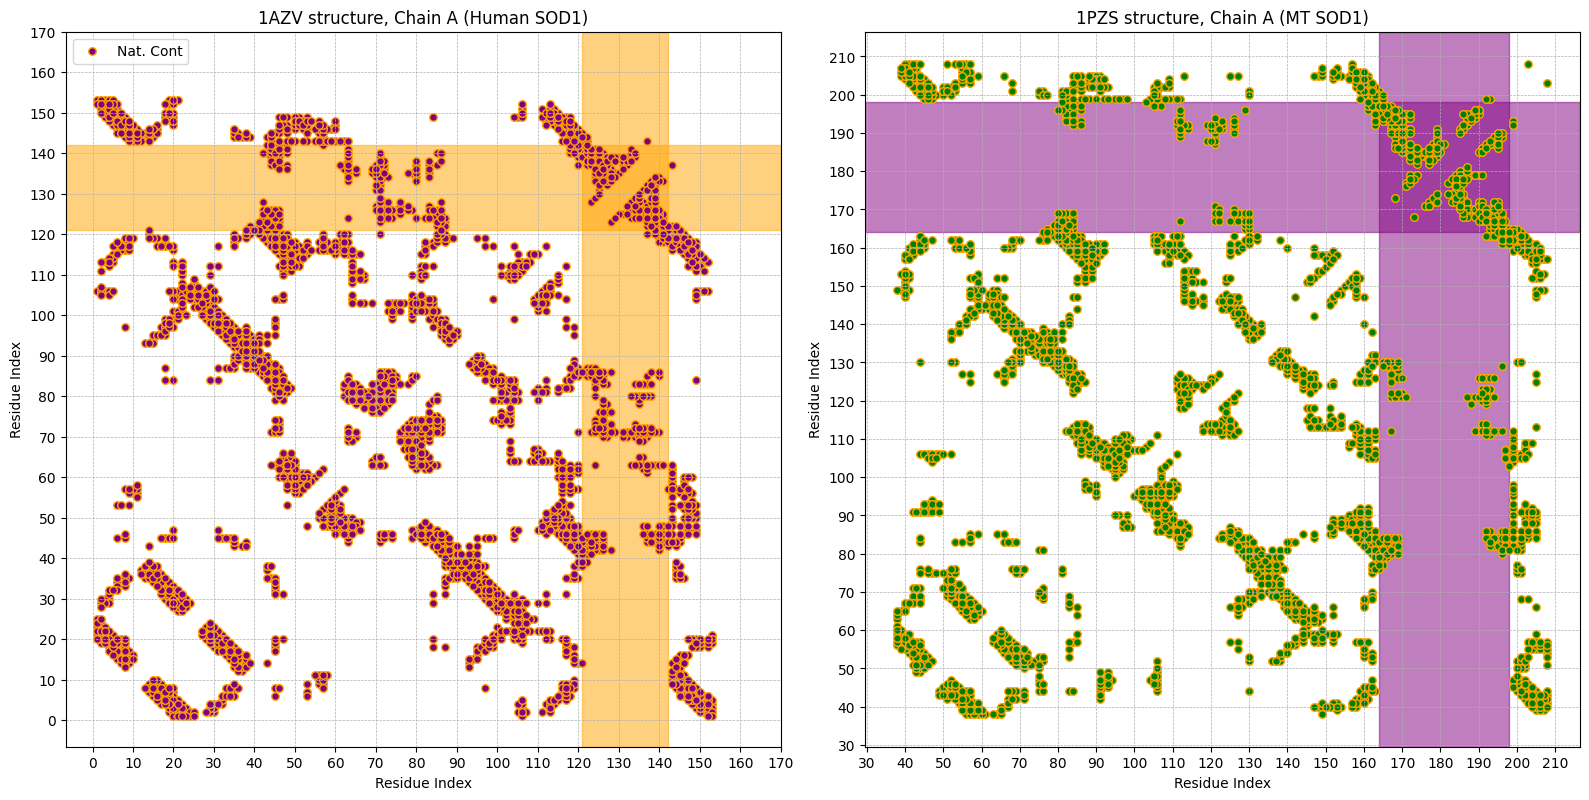

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].axvspan(121, 142, alpha=0.5, color='orange')
axes[0].axhspan(121, 142, alpha=0.5, color='orange')
axes[0].scatter(native_pairs1[:,1], native_pairs1[:,0], marker='o',
                s=30, label='Nat. Cont', facecolors='purple', edgecolors='orange');
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xticks(np.arange(0, 180, 10))
axes[0].set_yticks(np.arange(0, 180, 10))
axes[0].set_xlabel('Residue Index');
axes[0].set_ylabel('Residue Index');
axes[0].set_title(f'{pdbID_1} structure, Chain A (Human SOD1)')
axes[0].legend()

axes[1].axvspan(164, 198, alpha=0.5, color='purple')
axes[1].axhspan(164, 198, alpha=0.5, color='purple')
axes[1].scatter(native_pairs2[:,1], native_pairs2[:,0], marker='o',
                s=30, label='Nat. Cont', facecolors='green', edgecolors='orange');
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_xticks(np.arange(30, 211, 10))
axes[1].set_yticks(np.arange(30, 211, 10))
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlabel('Residue Index');
axes[1].set_ylabel('Residue Index');
axes[1].set_title(f'{pdbID_2} structure, Chain A (MT SOD1)')
axes[1].set_aspect('equal', adjustable='box')


plt.tight_layout();

## Step 2: Finding and preparing an MSA for our protein
Both versions of SOD belong to the samin family domain found in the Pfam database. The Pfam ID for this family is PF00080. Usually this is a good starting point to find an MSA for a protein, since Pfam is a curated database that contains high quality MSAs for many protein families, although it is not guaranteed that the MSA in Pfam will be the best one for your analysis. It is always a good idea to check the quality of the MSA and to compare it with other MSAs that you can find in other databases or that you can generate yourself.

As of 2023, Pfam is hosted on EBI here: https://www.ebi.ac.uk/interpro/entry/pfam/. Usually sending a request to the EBI API is the best way to get the MSA. You can also download the MSA directly from the website, but this can cause issues with big families. The Pfam MSA is available in Stockholm format, but we will need to convert it to FASTA format to use it for our analysis. There are several ways to do this, but one of the easiest ways is to use the `esl-reformat` tool from the HMMER suite, which can convert between different sequence formats. If you have access to HMMER, you can use the `easel apps` to convert from Stockholm to FASTA. If not, I've made available an alternative way to convert the MSA that my be a bit more brute force.

### Downloading the MSA from Pfam
We will request the compress Stockholm file and then uncompress it and convert it to FASTA format.

In [5]:
pfam_ID = 'PF00080'
zipFile = dataDir.joinpath('pfam_full_'+pfam_ID+'.stockholm.gz')
stockholmFile= dataDir.joinpath('pfam_full_'+pfam_ID+'.stockholm')

pfamRequest = get(f'https://www.ebi.ac.uk/interpro/wwwapi//entry/pfam/{pfam_ID}/?annotation=alignment:full&download')
with open(zipFile, 'wb') as fd:
    fd.write(pfamRequest.content)
unZipFile(zipFile, stockholmFile)

### Reformatting Stockholm to Fasta
You can use the following code to convert the Stockholm file to FASTA format. This code reads the Stockholm file, extracts the sequence names and sequences, and writes them to a new FASTA file. The code assumes that the Stockholm file is in the format where each sequence is represented by a line that starts with the sequence name followed by the sequence, and that the sequences are aligned (i.e., they have the same length and may contain gaps represented by dashes). Usually, this is done using the `esl-reformat` tool from the HMMER suite, which can convert between different sequence formats. If you have access to HMMER, you can use the `easel miniapps` to convert from Stockholm to FASTA. If not, I've made available an alternative way to convert the MSA that my be a bit more brute force.

In [1]:
fastaFile = dataDir.joinpath('pfam_full_'+pfam_ID+'.fasta')
seqs = defaultdict(str)

with open(stockholmFile, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#") or line.startswith("//"):
            continue
        parts = line.split()
        if len(parts) >= 2:
            name, seq = parts[0], parts[1]
            seqs[name] += seq

with open(fastaFile, "w") as out:
    for name, seq in seqs.items():
        out.write(f">{name}\n{seq}\n")

        # Remove lowercase letters and periods from the MSA, and save to a new file.
cleanFastaFile = fastaFile.with_name('clean_'+fastaFile.name)
helper_functions.clean_pfam( fastaFile, cleanFastaFile)

NameError: name 'dataDir' is not defined

### Filtering the Pfam MSA.
The Pfam MSA has many characters we do not use (lowercase letters and periods). After removing these characters, some sequences will have a large amounts of consecutive gaps. Consecutive gaps often add noise and detract from the quality of the analysis, so we do some filtering to remove sequences which have too many consecutive gaps. This notebook filters at 20% of the length of the aligned sequence, so a sequence of length 100 with 21 consecutive '-' characters is removed from the MSA.

This file will be saved with "filtered_" appended, and will be used for the rest of the analysis.

In [8]:
# Get final sequence length and calculate max number of consecutive gaps to allow
msa_gap_percentage = 20
pfam_domain_length = len(next(SeqIO.parse( cleanFastaFile ,'fasta')))
max_gaps = round( msa_gap_percentage * pfam_domain_length / 100 )

# Filter and save the MSA for use later in the notebook.
filteredFastaFile = fastaFile.with_name(f'filtered_{msa_gap_percentage}pct_'+fastaFile.name)
helper_functions.filter_pfam( str(cleanFastaFile), max_gaps, str(filteredFastaFile) )

Original number of sequences: 12880

Number(%) of sequences excluded: 893 (6.93%)



## Step 4: Run the analysis
Almost there! Now we can run DCA using the cleaned and filtered fasta file we've created. Then, we can use one of the outputs of DCA, the DI scores, to rank pairs of positions in the MSA by how strongly they are interacting.

The DI score is a measure of the strength of couplings between any two positions in the MSA. So if residue 1 and residue 20 are covarying (changing together) across all/most sequences in your dataset, then this might get a large DI score. If positions 2 and 19 do not seem to change with each other as you look at each individual sequence in the dataset, then this would get a lower DI score.

These days, performance is not a big issue for running DCA, so we will be using the mean-field implementation of DCA, which is the simplest and fastest implementation. There are more complex implementations that can give similar or better results, depending on what are we trying to achieve, but they are also more computationally intensive and can be difficult to run on a laptop. The mean-field implementation is a good starting point to learn about DCA and to get some results that you can work with.

Running the mean_field method of the dca class will:
1. Calculate the single site and pairwise frequencies,$f_i$ and $f_{ij}$, respectively. 
2. It will calculate the covariance of sites and use that to infer the couplings between sites, which are represented by the $e_{ij}$ matrix.
3. Using a Message Passing algorithm, it will calculate the fields $h_i$ that best explain the observed frequencies in the MSA. The fields represent the propensity of each amino acid to be at a given position, while the couplings represent the strength of the interaction between pairs of positions.
4. Finally, it will calculate the DI scores from the couplings and the single site frequencies. The DI scores are a measure of how strongly two positions in the MSA are interacting, and they can be used to predict contacts in the 3D structure of the protein.

In [9]:
# Run DCA with the cleaned/filtered MSA.
dca_model = dca_class.dca( str(filteredFastaFile))
dca_model.mean_field() # runs the analysis. Might take a while!

# print DCA Summary
print('Summary of MSA and Effective # of Sequences:')
print("M = "+str(dca_model.M)+' , N = '+str(dca_model.N))
print("Meff = "+ str(dca_model.Meff))

# Rank the pairs by DI score
ranked_DI_pairs = dca_model.DI[ np.argsort( dca_model.DI[:,2] )[::-1] ]
print('Top 10 DI pairs:')
print(ranked_DI_pairs[:10])

Summary of MSA and Effective # of Sequences:
M = 11988 , N = 133
Meff = 4796.168387077669
Top 10 DI pairs:
[[117.         118.           0.5812869 ]
 [114.         115.           0.42830813]
 [ 52.          53.           0.4202781 ]
 [ 33.          50.           0.39903338]
 [ 97.          98.           0.35442607]
 [119.         120.           0.33747526]
 [130.         131.           0.3257898 ]
 [ 62.          63.           0.31144715]
 [120.         121.           0.30555517]
 [126.         129.           0.30543689]]


## Step 5: Aligning our results with the structure and plotting
Now that we have the DI scores, we can rank the pairs of positions by their DI score and see how well they match the native contacts we calculated from the PDB structures. However, before we can do that, we need to make sure that the positions in the MSA are aligned with the positions in the PDB structures.

The MSA generated by Pfam will likely not look like the sequence of your real protein; it will often be shorter, or even a small subset of the protein you are looking at. It will also have deletions and insertions relative to your protein sequence. This is because the MSA was generated by trying to find generally consistent features of the "family" of protein domains and might not include your particular protein's residues.

This means that aligning your PDB of interest is not straightforward. Luckily the HMMER package makes this simple for you. The HMM file for your particular Pfam ID is in the "Model and Curation" tab on Pfam. This can be used to align any sequence to your MSA, because the MSA was made with the HMM file. This section downloads the HMM file, then uses a python wrapper of HMMER to align your pdb sequence. It returns a dictionary, mapping MSA coordinates to PDB coordinates. MSA position 1 -> PDB position 12, for example. If you don't have access to HMMER, I have provided a pickle file with the mapping for the PDBs we are working with, so you can skip this step and load the mapping from the pickle file.

In [10]:
# download hmm profile
HMMFile = dataDir.joinpath(pfam_ID+'.hmm')
zipHMMFile = HMMFile.with_suffix('.hmm.gz')
hmmRequest = get(f'https://www.ebi.ac.uk/interpro/wwwapi//entry/pfam/{pfam_ID}?annotation=hmm')
with open( zipHMMFile,'wb') as fd: 
    fd.write(hmmRequest.content)

unZipFile(zipHMMFile, HMMFile)

def get_alignment_dictionary(pfam_ID, structSeq,pickle_file):
    if pickle_file.exists():
        with open(pickle_file, 'rb') as f:
            alignment_dictionary = pickle.load(f)
    else:
        alignment_dictionary = hmm_tools.MapSeq2hmmProfile(HMMFile, structSeq)
        with open(pickle_file, 'wb') as f:
            pickle.dump(alignment_dictionary, f)
    return alignment_dictionary

alignDict1 = get_alignment_dictionary(pfam_ID, structSeq1, dataDir / f'alignment_dict_{pfam_ID}_{pdbID_1}.pkl')
alignDict2 = get_alignment_dictionary(pfam_ID, structSeq2, dataDir / f'alignment_dict_{pfam_ID}_{pdbID_2}.pkl')

In [15]:
alignDict1[109], alignDict1[126]

(121, 142)

Now we can use this mapping to align the DI pairs to the PDB coordinates.

We do some further processing:
- The DI pairs which are $<4$ positions away are often highly correlated/coupled (1 and 2, 1 and 3, etc). We're not interested in these positions, so we can filter them out to see distant pairs which are strongly coupled.
- We plot only a subset of the DI pairs after they're ranked and filtered. The DI metric gives a score for every possible pair of positions, and many of them will have very low scores. We plot the highest few because they have the best chance of being real interactions expected in any member of the protein/domain family. You can change these parameters in the script, but we will plot the top N=(length of alignment) pairs.

In [11]:
# Filter out pairs that are too close, and map pairs 
# with alignment dictionary from previous step
mapped_di_pairs1 = dca_analysis.map_filter_DIpairs(alignDict1, ranked_DI_pairs)
mapped_di_pairs2 = dca_analysis.map_filter_DIpairs(alignDict2, ranked_DI_pairs)

# Take top N pairs
numOfDIpairs = pfam_domain_length*2
top_N_pairs1 = mapped_di_pairs1[:numOfDIpairs,:2]
top_N_pairs2 = mapped_di_pairs2[:numOfDIpairs,:2]
UpperContacts1 = np.array([pair for pair in native_pairs1 if pair[0] < pair[1] ])
UpperContacts2 = np.array([pair for pair in native_pairs2 if pair[0] < pair[1] ])

def split_pairs_by_membership(pairs_to_split, reference_pairs, ignore_order=True):
    a = np.asarray(pairs_to_split, dtype=int)
    b = np.asarray(reference_pairs, dtype=int)

    if ignore_order:
        a_cmp = np.sort(a, axis=1)
        b_cmp = np.sort(b, axis=1)
    else:
        a_cmp = a
        b_cmp = b

    ref_set = {tuple(row) for row in b_cmp}
    mask_in_ref = np.array([tuple(row) in ref_set for row in a_cmp])

    return a[mask_in_ref], a[~mask_in_ref], mask_in_ref

# Example on your current pairs:
top_hits1, top_misses1, mask1 = split_pairs_by_membership(top_N_pairs1, UpperContacts1, ignore_order=True)
top_hits2, top_misses2, mask2 = split_pairs_by_membership(top_N_pairs2, UpperContacts2, ignore_order=True)

print(f"1AZV -> in native contacts: {len(top_hits1)}, not in native contacts: {len(top_misses1)}")
print(f"1PZS -> in native contacts: {len(top_hits2)}, not in native contacts: {len(top_misses2)}")

1AZV -> in native contacts: 185, not in native contacts: 81
1PZS -> in native contacts: 147, not in native contacts: 119


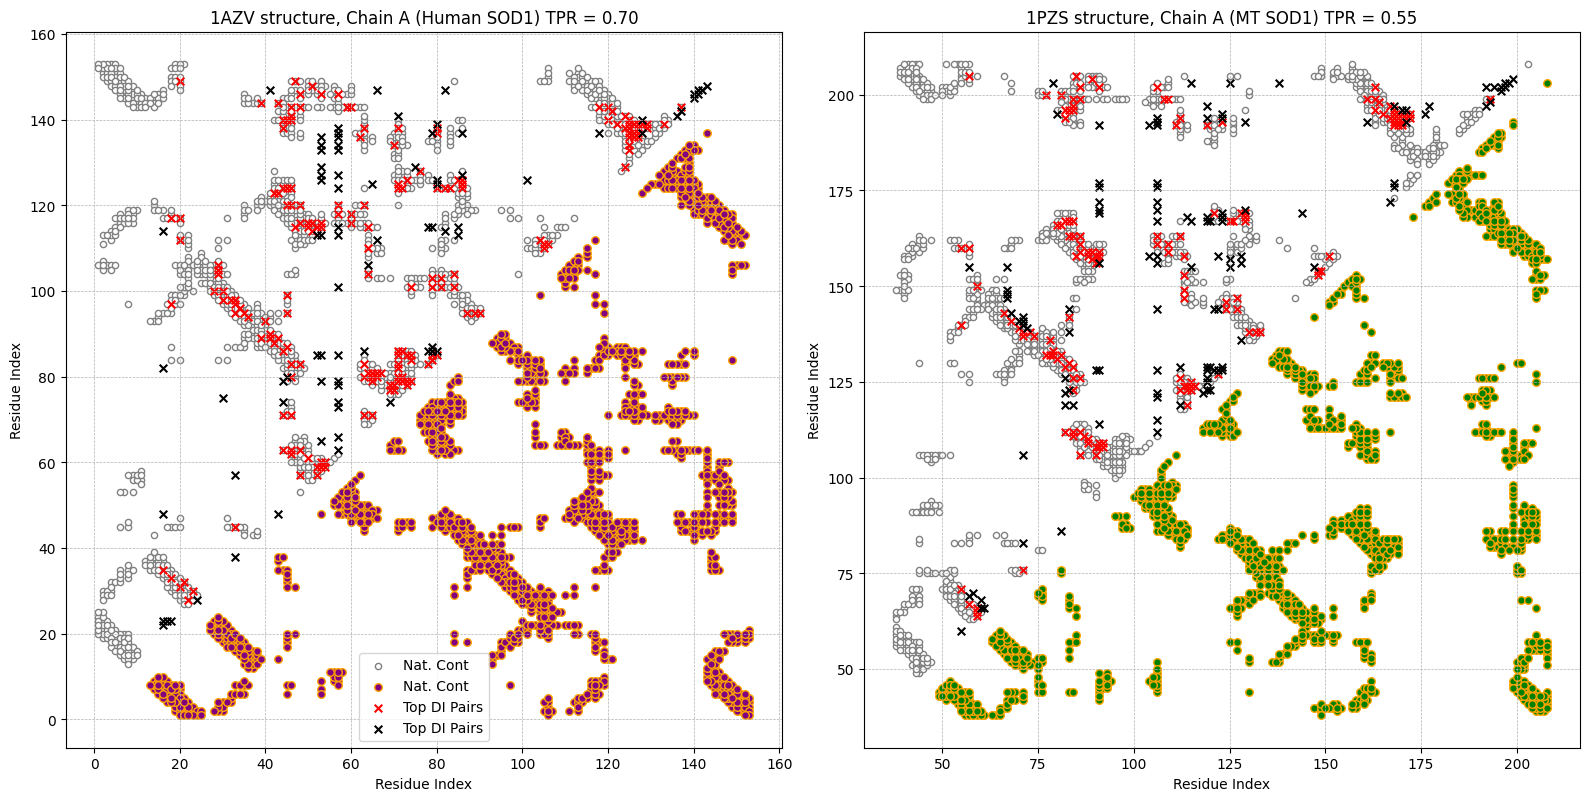

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].scatter(UpperContacts1[:,0], UpperContacts1[:,1], marker='o',
                s=20, label='Nat. Cont', facecolors='White', edgecolors='grey');
axes[0].scatter(UpperContacts1[:,1], UpperContacts1[:,0], marker='o',
                s=30, label='Nat. Cont', facecolors='purple', edgecolors='orange');
axes[0].scatter(top_hits1[:,0], top_hits1[:,1], marker='x',
                s=30, label='Top DI Pairs', color='red');
axes[0].scatter(top_misses1[:,0], top_misses1[:,1], marker='x',
                s=30, label='Top DI Pairs', color='black');
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel('Residue Index');
axes[0].set_ylabel('Residue Index');
axes[0].set_title(f'{pdbID_1} structure, Chain A (Human SOD1) TPR = {len(top_hits1)/numOfDIpairs:.2f}')
axes[0].legend()
    
axes[1].scatter(UpperContacts2[:,0], UpperContacts2[:,1], marker='o',
                s=20, label='Nat. Cont', facecolors='White', edgecolors='grey');
axes[1].scatter(UpperContacts2[:,1], UpperContacts2[:,0], marker='o',
                s=30, label='Nat. Cont', facecolors='green', edgecolors='orange');
axes[1].scatter(top_hits2[:,0], top_hits2[:,1], marker='x',
                s=30, label='Top DI Pairs', color='red');
axes[1].scatter(top_misses2[:,0], top_misses2[:,1], marker='x',
                s=30, label='Top DI Pairs', color='black');
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlabel('Residue Index');
axes[1].set_ylabel('Residue Index');
axes[1].set_title(f'{pdbID_2} structure, Chain A (MT SOD1) TPR = {len(top_hits2)/numOfDIpairs:.2f}')
axes[1].set_aspect('equal', adjustable='box')

plt.tight_layout();